In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../Datasets/Thyroid.csv")

df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
0,41.0,0.0,0,0,0,0,0,0,0,0,...,1,1.30,1,1,125.0,1.0,1.140,1,109.000000,0
1,23.0,0.0,0,0,0,0,0,0,0,0,...,1,4.10,1,1,102.0,0.0,0.995,0,110.469649,0
2,46.0,1.0,0,0,0,0,0,0,0,0,...,1,0.98,0,1,109.0,1.0,0.910,1,120.000000,0
3,70.0,0.0,1,0,0,0,0,0,0,0,...,1,0.16,1,1,175.0,0.0,0.995,0,110.469649,0
4,70.0,0.0,0,0,0,0,0,0,0,0,...,1,0.72,1,1,61.0,1.0,0.870,1,70.000000,0


In [4]:
df.shape

(3771, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3771 entries, 0 to 3770
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3771 non-null   float64
 2   on thyroxine               3771 non-null   int64  
 3   query on thyroxine         3771 non-null   int64  
 4   on antithyroid medication  3771 non-null   int64  
 5   sick                       3771 non-null   int64  
 6   pregnant                   3771 non-null   int64  
 7   thyroid surgery            3771 non-null   int64  
 8   I131 treatment             3771 non-null   int64  
 9   query hypothyroid          3771 non-null   int64  
 10  query hyperthyroid         3771 non-null   int64  
 11  lithium                    3771 non-null   int64  
 12  goitre                     3771 non-null   int64  
 13  tumor                      3771 non-null   int64

In [6]:
df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
count,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,...,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000,3771.000000
mean,51.628941,0.315379,0.123044,0.013259,0.011403,0.038982,0.014055,0.014055,0.015646,0.062053,...,0.902148,5.087823,0.796075,0.938743,108.316778,0.897375,0.994964,0.897905,110.471364,0.077168
std,18.980472,0.455393,0.328532,0.114397,0.106187,0.193577,0.117732,0.117732,0.124117,0.241283,...,0.297154,23.293851,0.402967,0.239833,34.500726,0.303509,0.185168,0.302813,31.359068,0.266893
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.005000,0.000000,0.000000,2.000000,0.000000,0.250000,0.000000,2.000000,0.000000
25%,36.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.600000,1.000000,1.000000,89.000000,1.000000,0.890000,1.000000,94.000000,0.000000
50%,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.600000,1.000000,1.000000,106.000000,1.000000,0.995000,1.000000,110.000000,0.000000
75%,67.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,3.800000,1.000000,1.000000,123.000000,1.000000,1.070000,1.000000,121.500000,0.000000
max,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,530.000000,1.000000,1.000000,430.000000,1.000000,2.320000,1.000000,395.000000,1.000000


In [7]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": round(df.isnull().mean()*100,2)
})

missing

,Missing,Percent
age,0,0.0
sex,0,0.0
on thyroxine,0,0.0
query on thyroxine,0,0.0
on antithyroid medication,0,0.0
sick,0,0.0
pregnant,0,0.0
thyroid surgery,0,0.0
I131 treatment,0,0.0
query hypothyroid,0,0.0


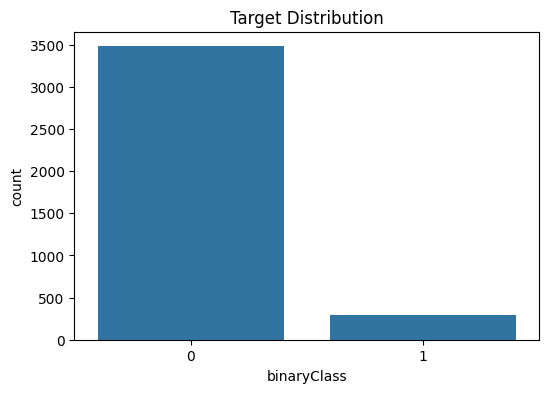

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='binaryClass',data=df)

plt.title("Target Distribution")

plt.show()

In [9]:
df['binaryClass'].value_counts()

binaryClass
0    3480
1     291
Name: count, dtype: int64

In [10]:
df['binaryClass'].value_counts()

binaryClass
0    3480
1     291
Name: count, dtype: int64

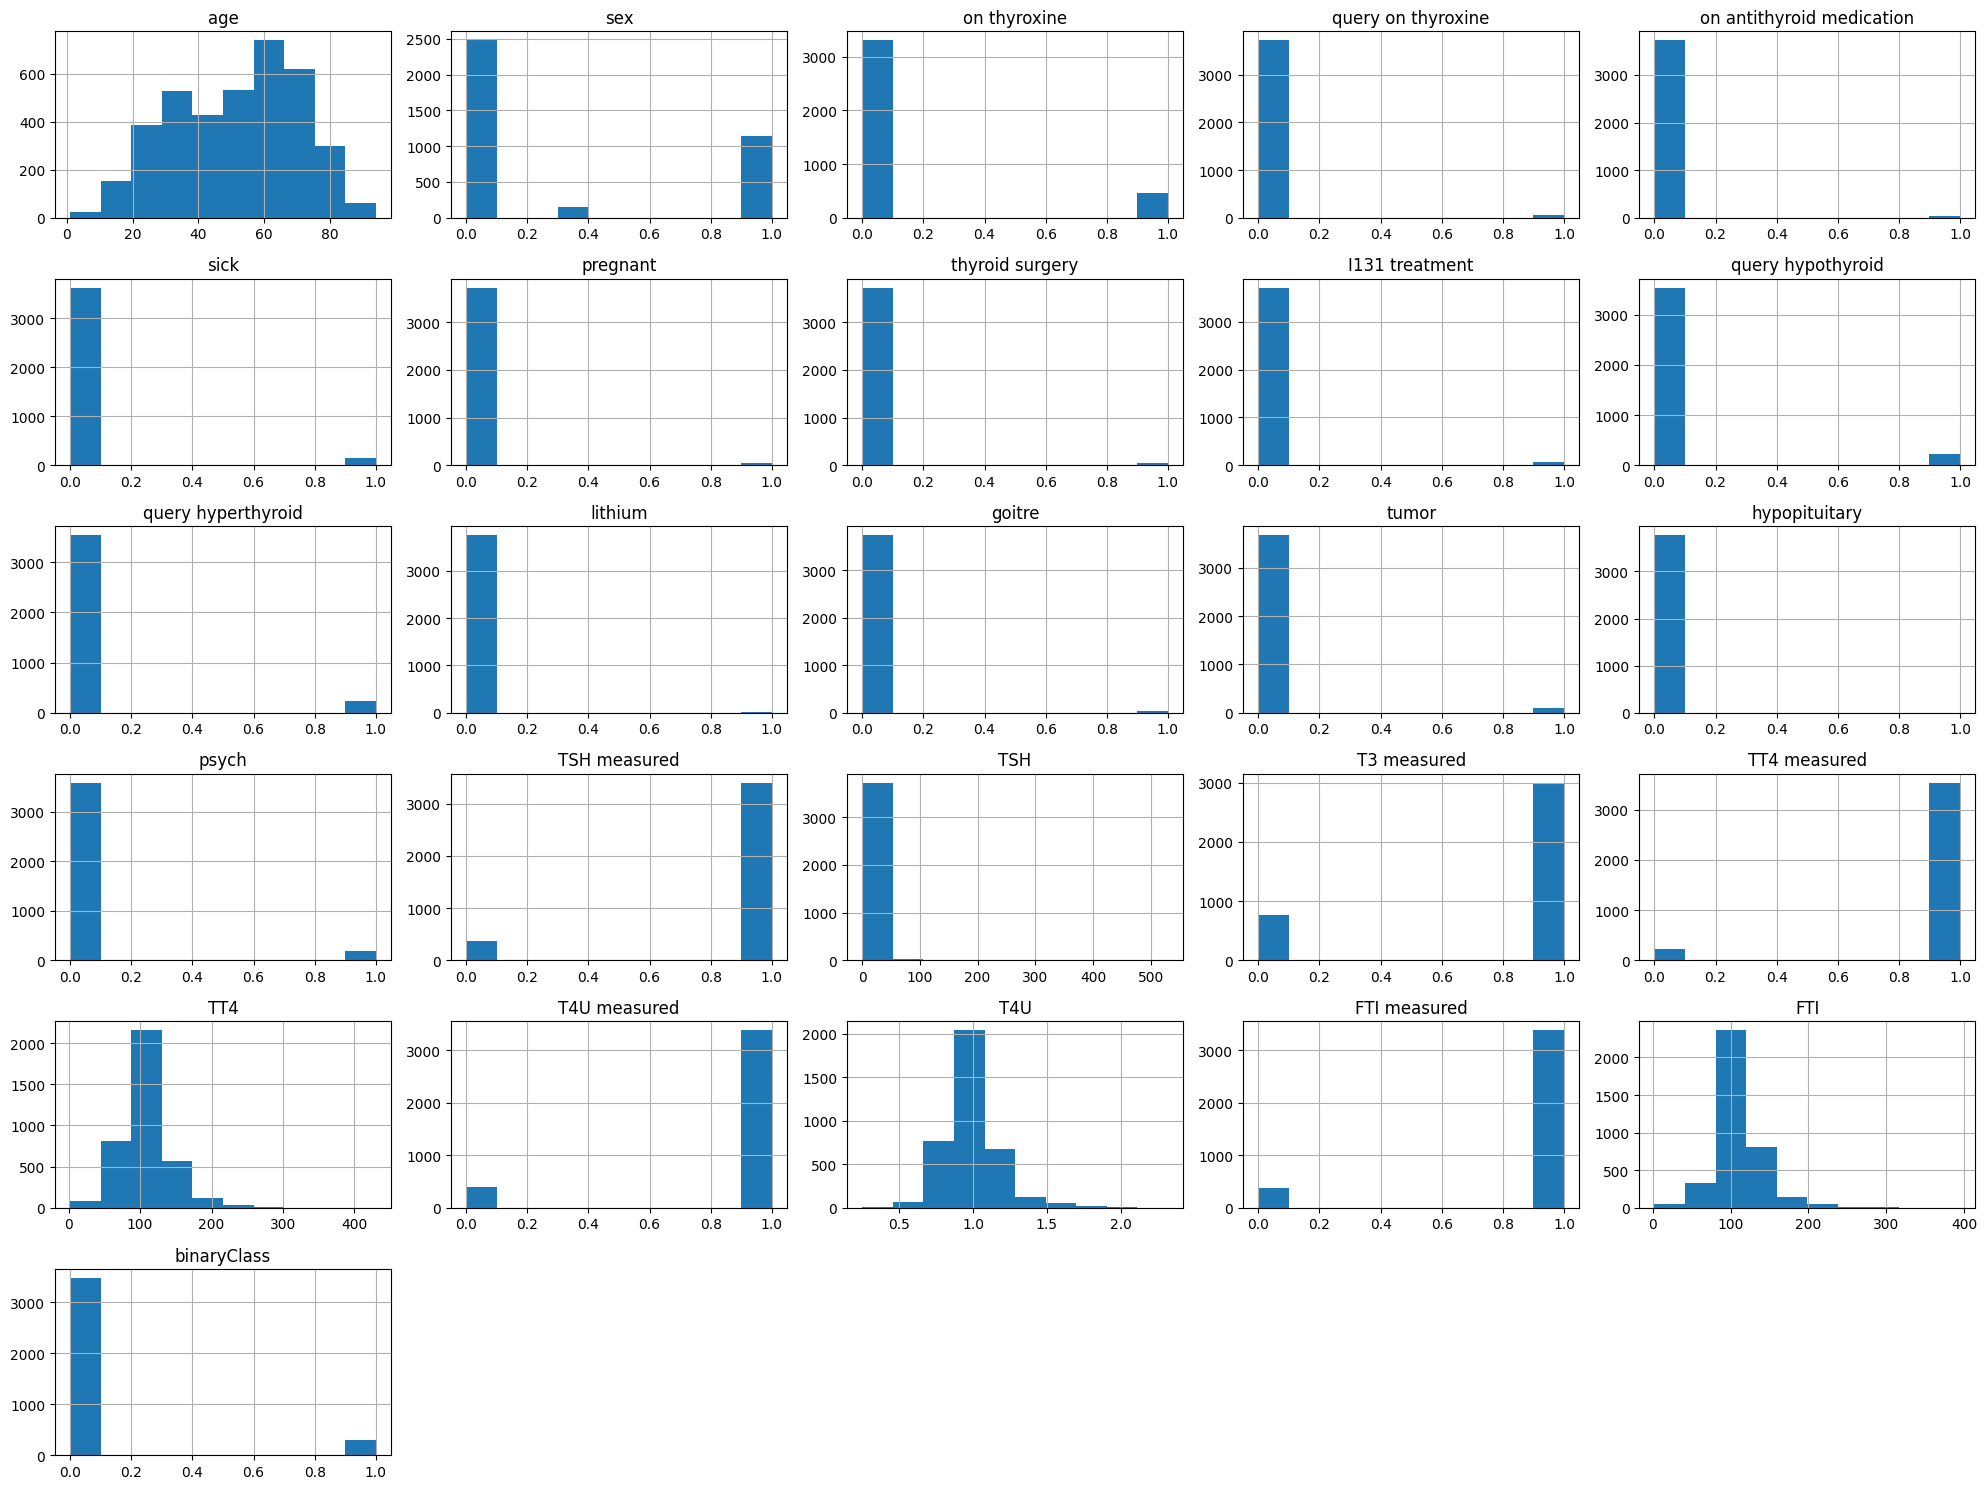

In [11]:
df.hist(figsize=(20,15))

plt.tight_layout()

plt.show()

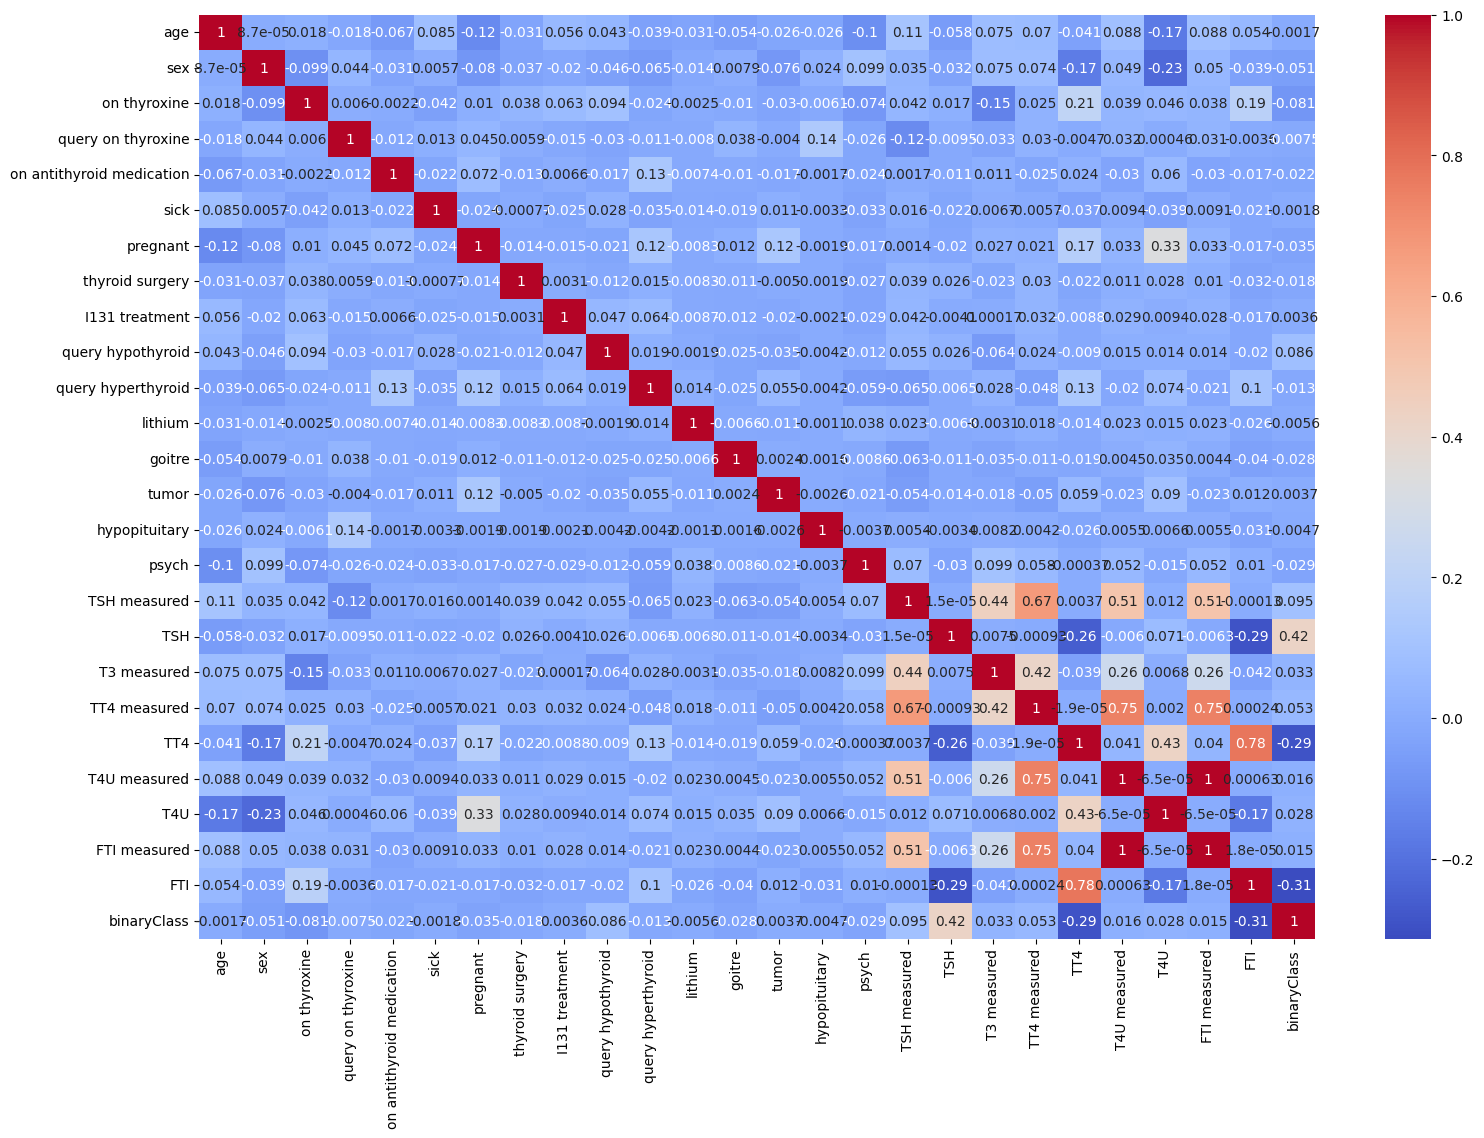

In [12]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(),cmap='coolwarm',annot=True)

plt.show()

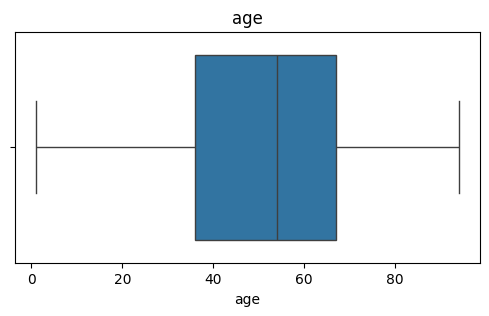

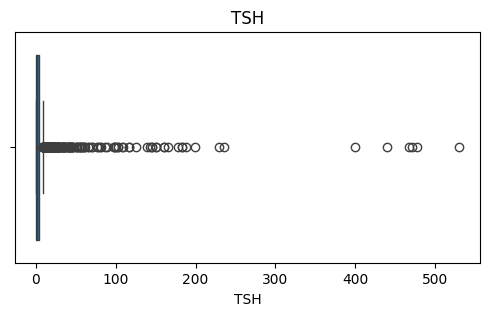

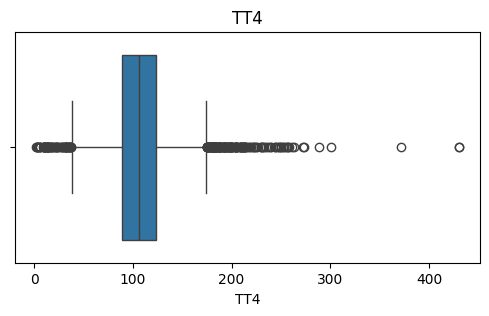

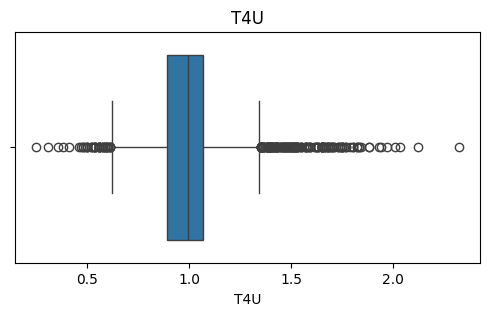

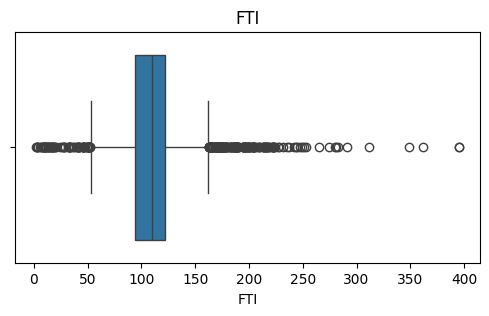

In [13]:
for col in ['age','TSH','TT4','T4U','FTI']:
    
    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

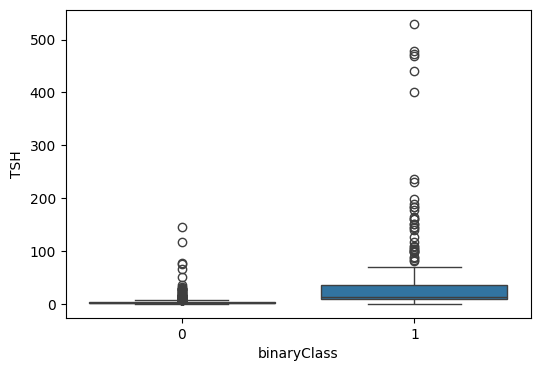

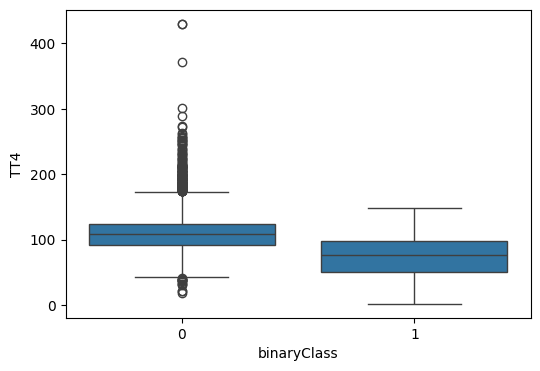

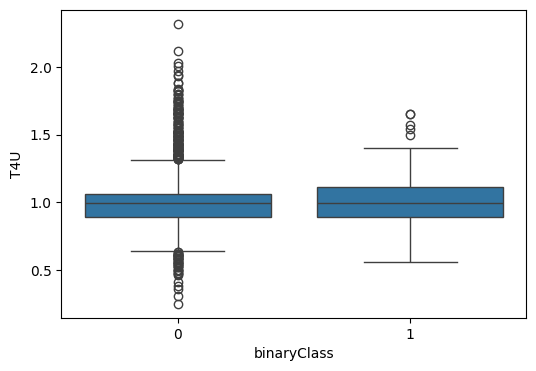

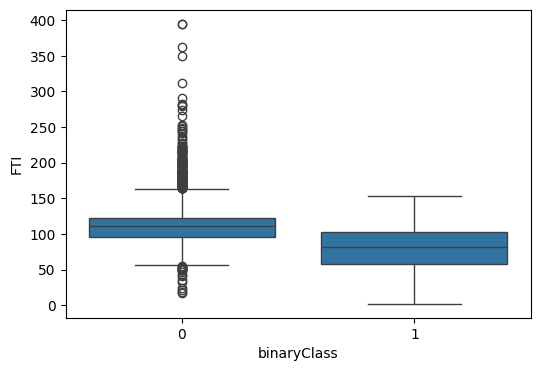

In [14]:
for col in ['TSH','TT4','T4U','FTI']:
    
    plt.figure(figsize=(6,4))

    sns.boxplot(x='binaryClass',y=col,data=df)

    plt.show()

In [3]:
X = df.drop('binaryClass',axis=1)

y = df['binaryClass']

X.columns

Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI'],
      dtype='object')

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [17]:
preprocessor = ColumnTransformer([
    ('num',StandardScaler(),X.columns)
])

In [30]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',LogisticRegression(max_iter=3000))
])

lr_pipeline.fit(X_train,y_train)

pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print("Accuracy:",lr_acc)

Accuracy: 0.9668874172185431


In [31]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',RandomForestClassifier,n_estimators=300,random_state=42))
])

rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print("Accuracy:",rf_acc)

Accuracy: 0.9973509933774835


In [32]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',XGBClassifier(
         n_estimators=500,
         max_depth=4,
         learning_rate=0.03,
         random_state=42,
         eval_metric='logloss'
     ))
])

xgb_pipeline.fit(X_train,y_train)

pred_xgb = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print("Accuracy:",xgb_acc)

Accuracy: 0.9960264900662251


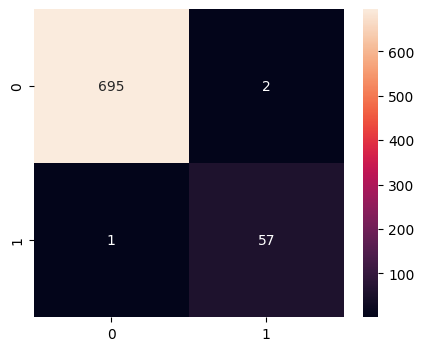

In [33]:
cm = confusion_matrix(y_test,pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [34]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[lr_acc,rf_acc,xgb_acc]
})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
1,Random Forest,0.997351
2,XGBoost,0.996026
0,Logistic Regression,0.966887


In [35]:
joblib.dump(
    xgb_pipeline,
    "thyroid_model.pkl"
)

['thyroid_model.pkl']

In [26]:
df['binaryClass'].value_counts()

binaryClass
0    3480
1     291
Name: count, dtype: int64

In [27]:
print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       697
           1       0.97      1.00      0.98        58

    accuracy                           1.00       755
   macro avg       0.98      1.00      0.99       755
weighted avg       1.00      1.00      1.00       755

